In [3]:
# from google.colab import files
# files.upload()
# !unzip /content/data.zip -d /content

## Sơ lược về dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_path = 'train.csv'
df = pd.read_csv(train_path)
df.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue,target
0,381,7337,1,100,4026532231,5,0,1
1,381,7337,1,100,4026532231,1,0,1
2,381,7337,1,100,4026532231,0,0,1
3,7347,7347,7341,0,4026531840,2,-2,1
4,7347,7347,7341,0,4026531840,4,0,1


📂 Mô tả tập dữ liệu

Bộ dữ liệu được cung cấp trong cuộc thi này ghi lại **hoạt động hệ thống cấp thấp từ môi trường Linux**, được thu thập thông qua **giám sát ở cấp độ kernel**.  
Mỗi hàng phản ánh **ảnh chụp nhanh về hành vi của tiến trình** hoặc **việc thực thi lệnh gọi hệ thống**, cung cấp một “mỏ vàng” để phát hiện các bất thường tinh vi trong các hoạt động ở cấp độ hệ điều hành.

Dữ liệu này **lý tưởng cho các nhiệm vụ**:
- Phát hiện bất thường (Anomaly Detection)
- Phân tích hành vi tiến trình
- Nghiên cứu an ninh mạng

---

📁 Các tệp trong bộ dữ liệu

| Tệp | Mô tả |
|------|--------|
| **`train.csv`** | Dữ liệu huấn luyện **có nhãn**, chứa thông tin chi tiết về tiến trình và lệnh gọi hệ thống. |
| **`test.csv`** | Dữ liệu **không có nhãn**, dùng để dự đoán trong quá trình đánh giá. |
| **`submission_sample.csv`** | Mẫu file nộp kết quả, bao gồm định dạng đầu ra dự kiến. Mỗi hàng nên chứa nhãn dự đoán bất thường (`0` hoặc `1`). |

---

🧬 Tổng quan về các đặc trưng

Mỗi hàng trong tập dữ liệu tương ứng với **một sự kiện hệ thống** (system event) — thường là một **lệnh gọi hệ thống (syscall)** hoặc **hành động của process**.

| Tên cột | Mô tả |
|----------|--------|
| **processId** | Mã định danh tiến trình duy nhất (PID) của tiến trình đang thực thi. |
| **threadId** | Mã định danh luồng (Thread ID) trong tiến trình — thường trùng với PID nếu tiến trình chỉ có một luồng. |
| **parentProcessId** | PID của tiến trình cha đã sinh ra tiến trình hiện tại. |
| **userId** | ID người dùng mà tiến trình chạy theo (`0` = root). |
| **mountNamespace** | Mã định danh không gian gắn kết (mount namespace) của Linux — thể hiện môi trường cô lập file system. |
| **argsNum** | Số lượng đối số (arguments) được truyền vào system call — chỉ ra độ phức tạp hoặc khả năng bị lạm dụng. |
| **returnValue** | Giá trị trả về từ system call — âm (`< 0`) là lỗi, `0` là thành công, dương (`> 0`) là trả về kết quả cụ thể. |
| **target** | Nhãn phân loại: `0` = bình thường, `1` = bất thường (chỉ có trong `train.csv`). |

---
🔍 Điểm nổi bật & Thông tin chi tiết

- Ghi lại **hoạt động của cả tiến trình có đặc quyền (root)** và **tiến trình người dùng thông thường**.  
- Theo dõi **mối quan hệ cha – con giữa các process**, hữu ích trong phân tích hành vi dòng dõi (lineage analysis).  
- Bao gồm thông tin **không gian tên (namespace)** — gợi ý khả năng liên quan đến container hoặc sandbox.  
- Ghi lại cả **siêu dữ liệu thực thi** lẫn **thông tin system call**, giúp quan sát hành vi hệ điều hành ở mức sâu.  

In [5]:
df.shape, df.duplicated().sum()

((763144, 8), 745674)

Dữ liệu bị trùng lặp khá nhiều, tuy nhiên đây là điều bình thường vì một tiến trình được user kích hoạt nhiều lần và được hệ thống ghi lại, không nên bỏ và cần các kĩ thuật xử lý phù hợp

In [6]:
summary = pd.DataFrame({
    'Tên cột': df.columns,
    'Số giá trị khác nhau': [df[col].nunique() for col in df.columns],
    'Kiểu dữ liệu': [df[col].dtype for col in df.columns]
}).sort_values('Số giá trị khác nhau', ascending=False)

summary.style.set_caption("📊 Thống kê số giá trị khác nhau theo từng cột")

,Tên cột,Số giá trị khác nhau,Kiểu dữ liệu
1,threadId,588,int64
0,processId,545,int64
6,returnValue,524,int64
2,parentProcessId,205,int64
3,userId,7,int64
4,mountNamespace,6,int64
5,argsNum,6,int64
7,target,2,int64


## Đơn biến

### processId

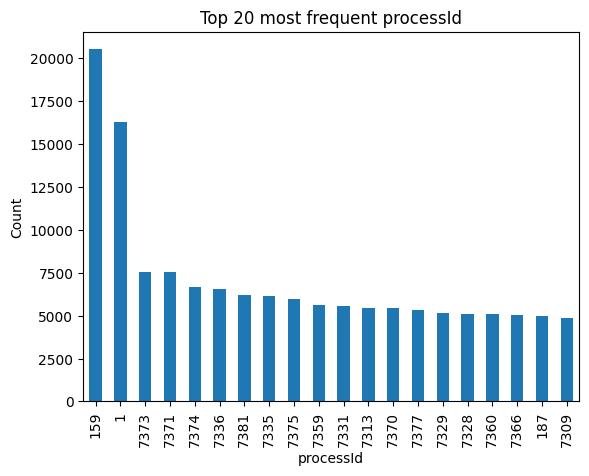

In [7]:
top_vals = df['processId'].value_counts().nlargest(20)
top_vals.plot(kind='bar')
plt.title("Top 20 most frequent processId")
plt.xlabel("processId")
plt.ylabel("Count")
plt.show()

Tiến trình **số 159** và **số 1** có tần suất xuất hiện rất cao trong log hệ thống:

- **Tiến trình số 1**: là tiến trình **khởi tạo chính** của hệ thống (thường là `init` hoặc `systemd`), chịu trách nhiệm **sinh ra hầu hết các tiến trình khác**, do đó xuất hiện với tần suất cao.
- **Tiến trình số 159**: thuộc nhóm **dịch vụ cốt lõi của hệ thống** khi khởi động (như quản lý mạng, môi trường, hoặc daemon nền), nên cũng có tần suất cao và hoạt động liên tục trong suốt phiên hệ thống.

### threadId

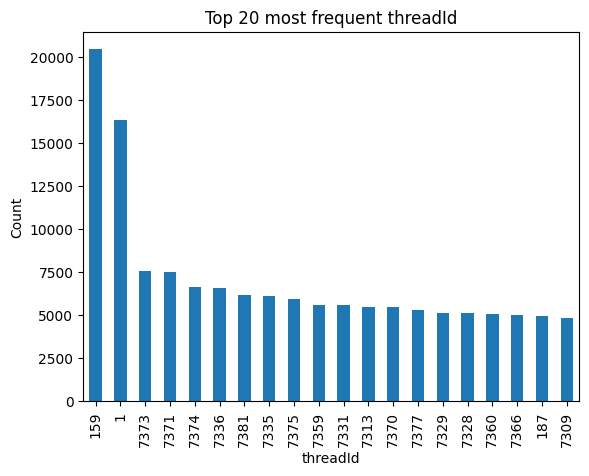

In [8]:
top_vals = df['threadId'].value_counts().nlargest(20)
top_vals.plot(kind='bar')
plt.title("Top 20 most frequent threadId")
plt.xlabel("threadId")
plt.ylabel("Count")
plt.show()

Hệ thống này **hầu như các tiến trình đều là đơn luồng**, do đó:

- Mỗi **`threadId`** gần như **trùng khớp với `processId`**.  
- Điều này cho thấy **mỗi tiến trình chỉ có một luồng thực thi chính**, không tạo thêm các luồng phụ.  
- Vì vậy, khi phân tích hành vi hoặc phát hiện bất thường (anomaly detection), có thể **coi tiến trình và luồng là tương đương nhau** trong hầu hết các trường hợp.


### parentProcessId

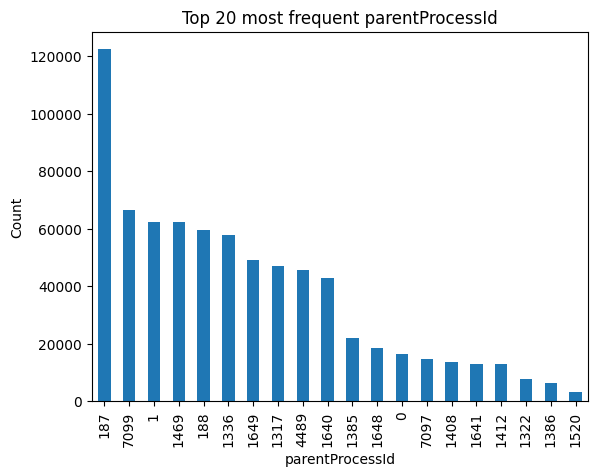

In [9]:
top_vals = df['parentProcessId'].value_counts().nlargest(20)
top_vals.plot(kind='bar')
plt.title("Top 20 most frequent parentProcessId")
plt.xlabel("parentProcessId")
plt.ylabel("Count")
plt.show()

Tiến trình số 187 và 7099 là hai dịch vụ cốt lõi nhất trong hệ thống,
chịu trách nhiệm quản lý và tạo ra nhiều tiến trình con khác.

Bên cạnh đó, tiến trình 1 – tiến trình khởi tạo chính của hệ thống –
vẫn xuất hiện với tần suất cao, phản ánh vai trò trung tâm của nó trong việc sinh ra hầu hết các tiến trình ban đầu.

Biểu đồ cho thấy sự phân bố lệch phải rõ rệt, với một số tiến trình cha có tần suất sinh tiến trình con vượt trội,
cho thấy cấu trúc hệ thống có một số ít tiến trình quản lý trung tâm, trong khi phần lớn còn lại là các tiến trình con phụ thuộc.

### argsNum

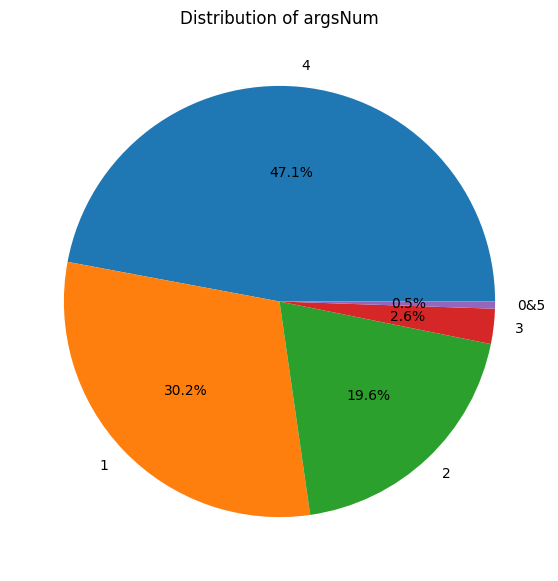

In [10]:
# Gộp giá trị 0 và 5 vào một nhóm
df['argsNum_grouped'] = df['argsNum'].apply(lambda x: '0&5' if x in [0, 5] else str(x))

# Đếm tần suất từng nhóm
counts = df['argsNum_grouped'].value_counts()
df.drop(columns='argsNum_grouped', inplace=True)
# Vẽ pie chart
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of argsNum")
plt.show()

Phần lớn các hàm trong tiến trình có từ 1 → 4 tham số, cho thấy đây là những hàm quan trọng và phổ biến,
được thiết kế với bộ tham số vừa đủ để đảm bảo tính linh hoạt, dễ quản lý và bảo trì.

Ngược lại, các hàm có từ 5 tham số trở lên xuất hiện với tần suất thấp,
do đây thường là những hàm phức tạp, khó mở rộng hoặc bảo trì, nên ít được gọi trong hệ thống thực tế.

Ngoài ra, các hàm không có tham số (argsNum = 0) chiếm tỷ lệ nhỏ,
vì chúng thường có mức độ tái sử dụng và tính linh hoạt thấp,
chỉ phù hợp cho một số tác vụ tĩnh hoặc đơn giản.

### returnValue

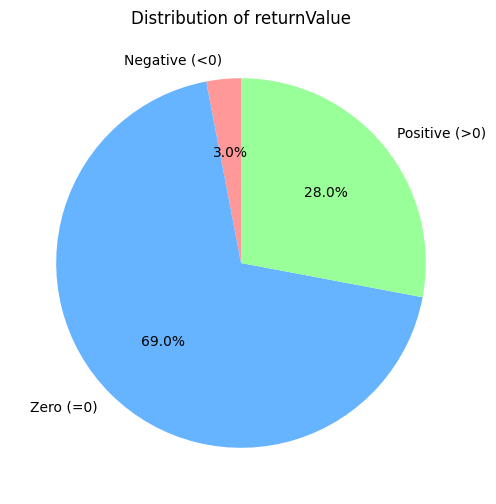

In [11]:
# Giả sử df là dataframe của bạn
counts = pd.Series({
    'Negative (<0)': (df['returnValue'] < 0).sum(),
    'Zero (=0)': (df['returnValue'] == 0).sum(),
    'Positive (>0)': (df['returnValue'] > 0).sum()
})

# Vẽ pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Distribution of returnValue")
plt.show()

Phần lớn các tiến trình và hàm chạy thành công (returnValue >= 0), chiếm tỉ lệ chủ đạo trong hệ thống.
Tuy nhiên, tỉ lệ chạy lỗi cũng không nhỏ — khoảng 17.6%,
điều này là dấu hiệu cần được theo dõi sát sao.

Khi tỉ lệ lỗi tăng đột ngột, đây có thể là dấu hiệu bất thường (anomaly) trong hệ thống,
phản ánh vấn đề trong tiến trình, luồng hoặc môi trường thực thi.
Vì vậy, cần kiểm tra chi tiết các tiến trình sinh lỗi để xác định nguyên nhân và ngăn ngừa sự cố lan rộng.

### target

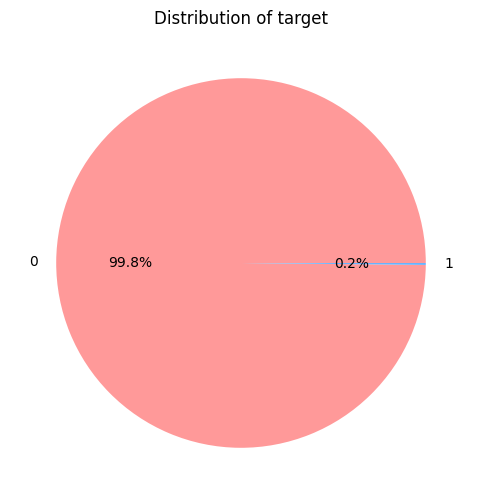

In [12]:
counts = df['target'].value_counts()

# Vẽ pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Distribution of target")
plt.show()

Dữ liệu hiện tại bị mất cân bằng nhãn khá nghiêm trọng,
trong đó các mẫu bình thường chiếm đa số, còn các mẫu bất thường (anomaly) chỉ chiếm tỷ lệ rất nhỏ.

Đây là đặc điểm phổ biến và hoàn toàn bình thường trong các bài toán Anomaly Detection,
bởi vì trong thực tế, hành vi bất thường chỉ xảy ra hiếm hoi so với hoạt động thông thường của hệ thống.

Tuy nhiên, sự mất cân bằng này gây khó khăn cho mô hình học máy,
vì mô hình có thể thiên lệch về lớp bình thường và bỏ sót các mẫu anomaly.
Do đó, cần áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu, chẳng hạn như:

Tái lấy mẫu (Resampling):

Oversampling (SMOTE, ADASYN) để tăng số mẫu anomaly.

Undersampling để giảm bớt số mẫu bình thường.

Điều chỉnh trọng số (Class weighting) trong quá trình huấn luyện.

Sử dụng các thuật toán chuyên biệt cho anomaly detection như Isolation Forest, One-Class SVM, ...

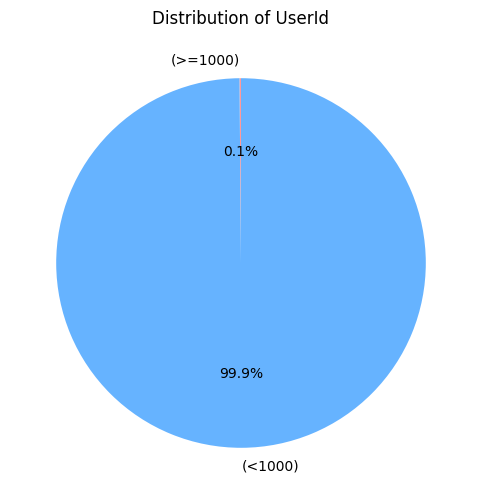

In [69]:
# Giả sử df là dataframe của bạn
counts_Id = pd.Series({
    '(>=1000)': (df['userId'] >= 1000).sum(),
    '(<1000)': (df['userId'] < 1000).sum()
})

# Vẽ pie chart
plt.figure(figsize=(6,6))
plt.pie(counts_Id, labels=counts_Id.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Distribution of UserId")
plt.show()

## Hai biến

In [44]:
(df['userId'] >= 1000).sum(),

(996,)

In [21]:
df.shape

(763144, 8)

In [13]:
df.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue,target
0,381,7337,1,100,4026532231,5,0,1
1,381,7337,1,100,4026532231,1,0,1
2,381,7337,1,100,4026532231,0,0,1
3,7347,7347,7341,0,4026531840,2,-2,1
4,7347,7347,7341,0,4026531840,4,0,1


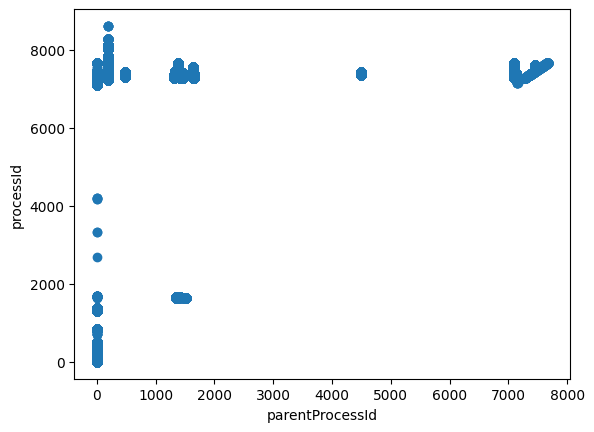

In [64]:
plt.scatter(df['parentProcessId'], df['processId'])
plt.xlabel('parentProcessId')
plt.ylabel('processId')
plt.show()


- Có nhiều điểm tập trung ở x ≈ 0 (các tiến trình gốc).
- Một vài cụm ở  1000 < x < 2000, 4000 < x < 5000,x > 7000 → phản ánh các tiến trình cha chính. (ứng dụng người dùng, tiến trình nền, dịch vụ, ...)
- Không có đường chéo hoặc cụm cực kỳ dày.
- → chưa có dấu hiệu anomaly rõ rệt.


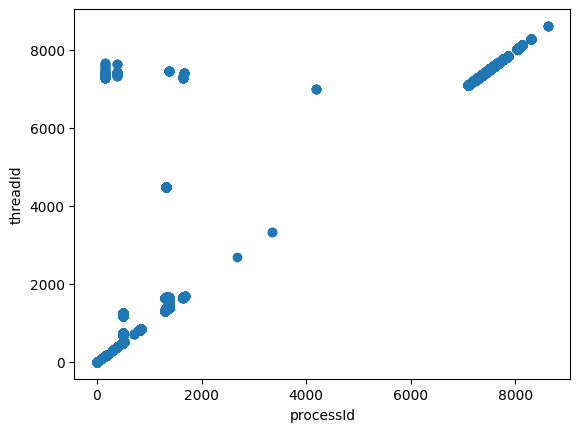

In [65]:
plt.scatter(df['processId'], df['threadId'])
plt.xlabel('processId')
plt.ylabel('threadId')
plt.show()


- Có các cụm dọc rõ ràng, mỗi cụm tương ứng với một process.
- Một số process có nhiều thread hơn những cái khác.
- Không thấy thread rải lung tung hoặc cột quá cao bất thường 
→ không có anomaly rõ ràng.

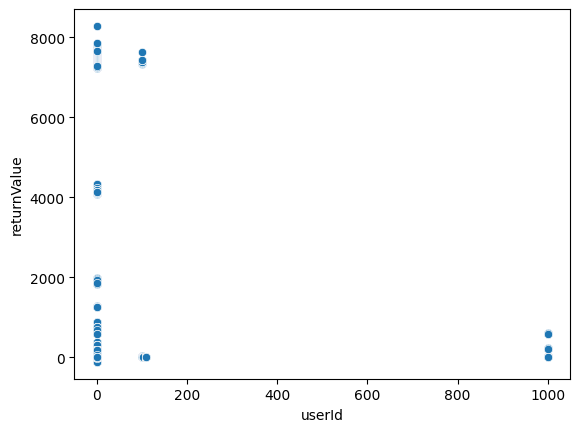

In [55]:
sns.scatterplot(data=df, x='userId', y='returnValue')
plt.show()

- userId tập trung phần lớn dưới 100: returnValue trải dài từ thấp đến rất cao (từ dưới 0 đến hơn 8000). => userId nhỏ (root/ system) là tài khoảng hệ thống nhưng vẫn xuất hiện lỗi. Nguyên nhân có thể từ các process nghiệp vụ
- userId >= 1000: returnValue vẫn cao. => Mức báo động vì các user này thường là người dùng được tạo sau hoặc không thuộc hệ thống gốc => Khả năng malicious hoặc process tùy biến.
- *Note: Malicious user có thể là người dùng thực hiện hành vi bất thường do có chủ đích gây hại cho hệ thống.
+ Malicious activity: Hoạt động độc hại (ví dụ hacker tấn công hệ thống).
+ Malicious code / malware: Mã độc hại như virus, trojan, ransomware.
+ Malicious user: Người dùng có hành vi cố tình gây lỗi, phá hoại, tấn công hệ thống.

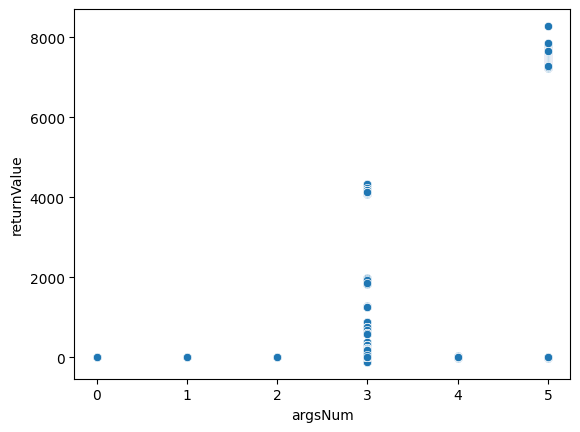

In [58]:
sns.scatterplot(data=df, x='argsNum', y='returnValue')
plt.show()

- argsnum = {0, 1, 2, 4}: return value nhỏ => bình thường.
- argsnum = 3: có nhiều điểm tập trung với returnValue cao (bình thường). Xuất hiện returnValue âm => Thất bại nhiều lần => có thể là brute-force API hoặc thăm dò hệ thống.
- argsnum = 5: có những điểm ở returnValue 7000 -> 8500 được coi là những điểm ngoại lai so với nhóm khác. (Cấp phát bộ nhơ slowns, tạo socket hoặc tiến trình con, hành vi truy cập vùng nhớ sâu (gần với malware))
=> Có khả năng malicious / anomaly

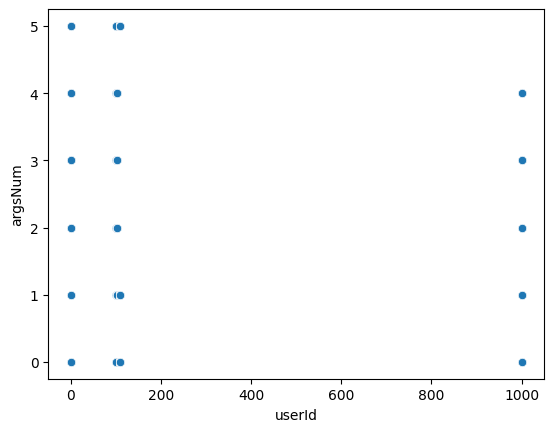

In [59]:
sns.scatterplot(data=df, y='argsNum', x='userId')
plt.show()

- userId nhỏ (99.9%) → argsNum phân bố từ 0 đến 5.
- userId 1000 (0.1%) → argsNum từ 0 đến 4 khác so với phần lớn các user còn lại.
=> Dấu hiệu cho anomaly

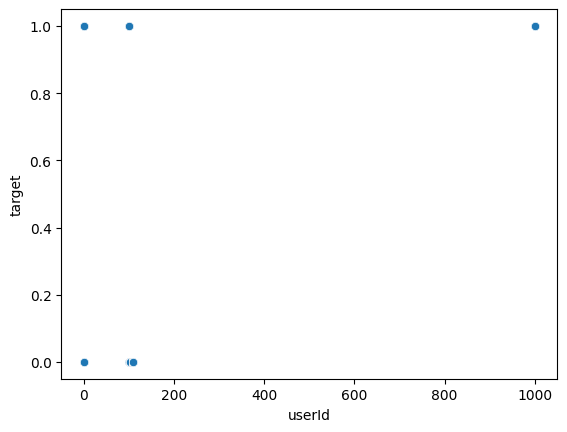

In [57]:
sns.scatterplot(data=df, x='userId', y='target')
plt.show()

- userId >= 1000 luôn xảy ra bất thường  => người dùng bình thường chạy tiến trình nặng bất thường => CPU hoạt động quá mức
- userid thấp vẫn có hành vi bất thường 

- => userId là yếu tố quan trọng trong việc phát hiện anomaly

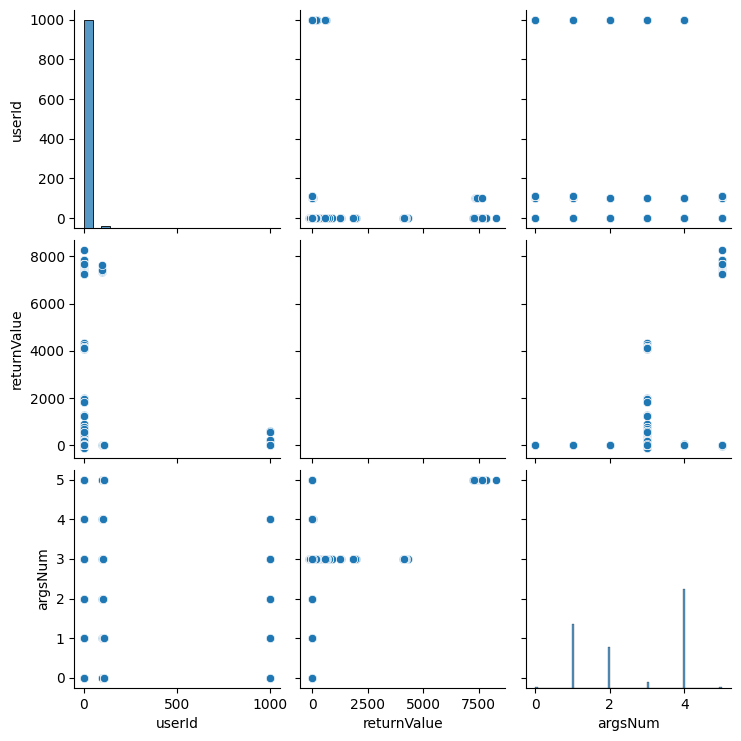

In [41]:
sns.pairplot(df, vars=['userId','returnValue', 'argsNum'])
plt.show()


- user 1000 returnvalue 100-> 1000 với argnums từ 1 -> 4 : xuất hiện giá trị âm (tổng là 504 giá trị) => có thể là bot hoặc các tác nhân không hợp lệ.
- còn các user khác là return value từ  < 0  đến > 8000 và retrunvalue từ 1-> 5: Dấu hiệu hệ thống API có các loại phản hồi đa dạng tùy hành vi hoặc lỗi

In [ ]:
((df['userId'] >= 1000) & (df['returnValue'] < 200)).sum()

24

In [ ]:
((df['userId'] >= 1000) & (df['returnValue'] < 0)).sum()

504

In [52]:
((df['userId'] < 1000) & (df['returnValue'] < 0)).sum()

22523

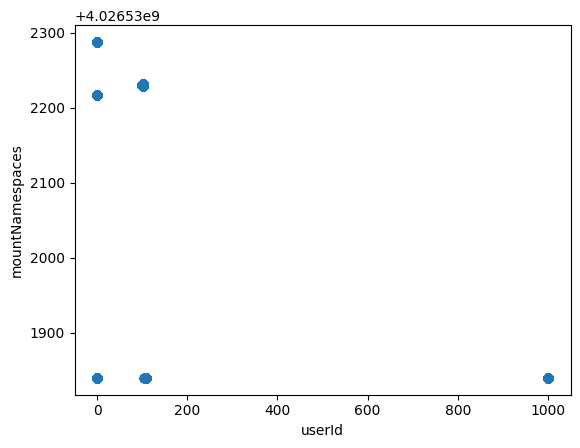

In [75]:
plt.scatter(df['userId'], df['mountNamespace'])
plt.xlabel('userId')
plt.ylabel('mountNamespaces')
plt.show()

- Nếu tiến trình user không phải root nhưng truy cập namespace đặc biệt → nguy cơ escalate privilege
- vì User bình thường (không phải root) chỉ được phép vào các namespace mà quyền của họ cho phép. Nhưng nếu user này truy cập được namespace đặc biệt cấp hệ thống → đó là hành vi nguy hiểm.
- => userId >= 1000 vẫn có thể tồn tại mountNamespaces trùng với root (userid ~ 0)=> cảnh báo bất thường 

# ***Đa biến***

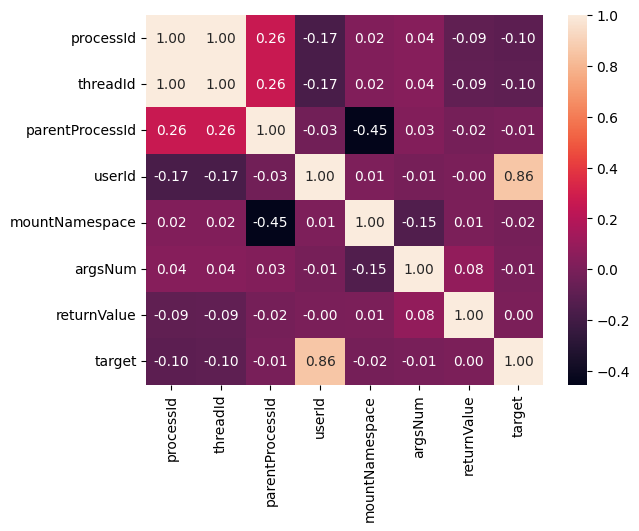

In [19]:
corrmatrix = df.corr()

sns.heatmap(corrmatrix, annot=True, fmt=".2f")
plt.show()

- Ta thấy UserId ảnh hưởng lớn nhất tới target (0.86) <=> Nguyên nhân do các userId >= 1000 (chiếm 0.1%) tất cả đều trả về trạng thái bất thường.
- processId - threadId (~1.00): tuyến tính, gần như trùng khớp hoàn toàn với nhau => loại bỏ 1 biến để tránh sự trùng lặp.
- parentProcessId - mountNamespace(~-0.45): Tương quan nghịch vừa phải => Các tiến trình cha có xu hướng thuộc các namespace khác nhau.